<a href="https://colab.research.google.com/github/davidriveraarbelaez/Optativa3_Agentes_IA/blob/main/ejemplo_agente.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%%capture
!pip install -U langchain langgraph langchain-anthropic langchain_google_genai tavily-python

# Conceptos clave

- **Estado (state):** Diccionario que lleva la información del agente durante su ejecución. Por ejemplo: mensajes, decisiones, resultados.

- **Nodos**: Funciones que actualizan el estado. Por ejemplo: llamar al modelo, ejecutar la herramienta.

- **Bordes (edges):** Reglas que dicen a qué nodo ir después. Pueden ser condicionales.

# Agente básico con LangGraph

Funciones / tareas del agente:
- Recibir una pregunta.
- Usar un LLM para responder.
- Terminar

In [ ]:
# Importaciones
from typing import Annotated, Sequence
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
from google.colab import userdata
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from typing_extensions import TypedDict
import operator

In [ ]:
import os
from google.colab import userdata
os.environ["GOOGLE_API_KEY"] = userdata.get('GEMINI_API_KEY')

# Definir el estado
Usar **add_messages** para que LangGraph sepa cómo acumular mensajes.

In [ ]:
class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# Crear el modelo

In [ ]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.3,
    max_tokens=1000,
    google_api_key=userdata.get('GEMINI_API_KEY'),
    streaming=True #
)

# Definir un nodo: el agente

In [ ]:
def call_model(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

# Este nodo toma el historial de mensajes y le pide al LLM que responda.

# Construir el grafo

In [ ]:
graph_builder = StateGraph(State)
graph_builder.add_node("agent", call_model)
graph_builder.add_edge(START, "agent")
graph_builder.add_edge("agent", END)
graph = graph_builder.compile()

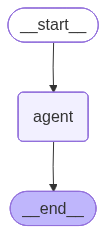

In [ ]:
from IPython.display import display, Markdown, Image

# Generar el diagrama de Mermaid
mermaid_diagram = graph.get_graph().draw_mermaid()

# Mostrar el diagrama como Markdown
#markdown_output = "```mermaid\n" + mermaid_diagram + "\n```"
#display(Markdown(markdown_output))

Image(graph.get_graph().draw_mermaid_png())


Este código primero obtiene la representación del grafo utilizando `graph.get_graph()`, luego genera el código del diagrama de Mermaid con `draw_mermaid_jr()` y finalmente lo muestra en el cuaderno utilizando `IPython.display.Markdown` o la imagen del agente con `draw_mermaid_png`.

# Ejecutar el agente

In [ ]:
# Ejemplo de uso
result = graph.invoke({"messages": [HumanMessage(content="¿Cuál es la capital de Portugal?")]})
print(result["messages"][-1].content)

NameError: name 'llm' is not defined

In [ ]:
from IPython.display import display, Markdown
display(Markdown(result["messages"][-1].content))

NameError: name 'result' is not defined